# VortexTech Week 1 — Data Cleaning and Basic Visualization

**Dataset:** Titanic passenger dataset (Kaggle) — 891 rows, mix of numeric and categorical columns.

**Goal:** Clean the dataset (missing values, duplicates, data types) and produce visualizations
that reveal basic patterns in the data.

In [1]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Load the Dataset

In [2]:
# load datasets
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Step 2: First Look at the Data
Checking the shape, column names, and data types before doing anything else.

In [3]:
# first 5 row check
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# check the columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

## Step 3: Check and Handle Missing Values

Checking which columns have missing values first, then deciding how to handle each one.

In [6]:
# check the missing value

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Age** has 177 missing values (about 20% of the data). I filled these with the
**median** instead of the mean, because Age has some outliers (very young/old passengers) that
would pull the mean away from a typical value — the median is more robust to that.

In [7]:
# handle the missing value 
# mean = df["Age"].mean()
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

**Cabin** is missing for about 687 out of 891 rows (over 75%). Since most of the
column is empty, filling it wouldn't be reliable, so I dropped the column entirely instead of
guessing values for three-quarters of the data.

In [8]:
df.drop(columns=["Cabin"],inplace=True)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


**Embarked** is only missing 2 values, so I filled those with the **mode**
(the most common port passengers boarded from) since it's such a small number of missing rows
that this won't meaningfully change the data.

In [10]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"] 

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

Double-checking that all missing values are handled:

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Step 4: Check and Remove Duplicate Rows

In [12]:
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


## Step 5: Check and Fix Data Types

Checking the data type of each column. Some columns are stored as numbers but are actually
categories (e.g. Survived is 0/1, Pclass is 1/2/3), so I converted them to the "category" type.
This doesn't change the values, but it makes it clearer that these aren't quantities to do math
on, and some plotting functions handle categories better.

In [13]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object

In [14]:
# Survived and Pclass are numbers in the file, but they're really categories, not quantities
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

df.dtypes

PassengerId       int64
Survived       category
Pclass         category
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Embarked       category
dtype: object

## Step 6: Summary Statistics
Quick look at the numeric columns after cleaning.

In [15]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.361582,0.523008,0.381594,32.204208
std,257.353842,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


## Step 7: Visualizations

Now that the data is clean, I made 5 charts to explore some basic questions about the Titanic
passengers: who survived, what class they travelled in, how old they were, and how survival
relates to age. I used `seaborn` for most of these since it works nicely with pandas DataFrames.

In [16]:
import seaborn as sns
sns.set_style("whitegrid")

### Chart 1: Age Distribution (Histogram)
Question: What did the age spread of passengers look like?

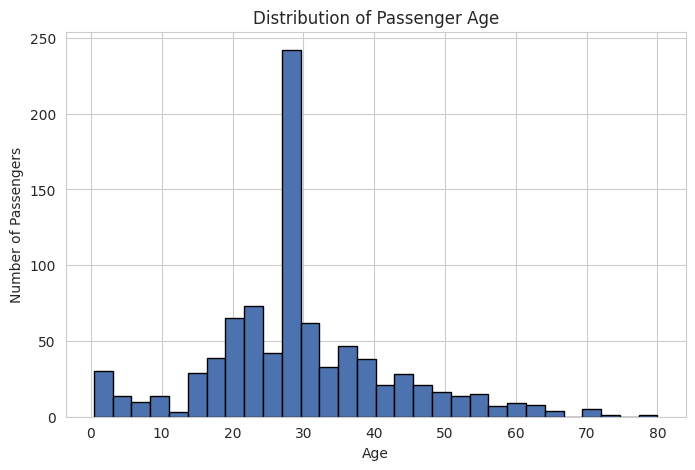

In [17]:
plt.figure(figsize=(8,5))
df["Age"].hist(bins=30, color="#4C72B0", edgecolor="black")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

**Insight:** Most passengers were between 20 and 40 years old, with a smaller number of
children and very few elderly passengers. The big bar around age 28 is partly because that's the
median value I used to fill in the missing ages.

### Chart 2: Passenger Count by Class (Bar Chart)
Question: Which travel class had the most passengers?

/tmp/ipykernel_525/741056733.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Pclass", palette="Blues_d")


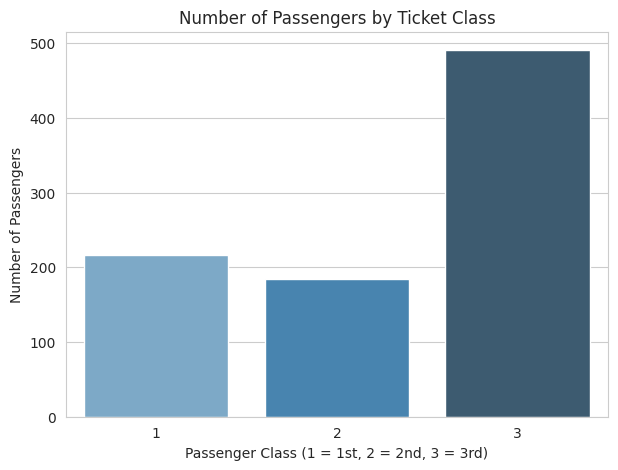

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Pclass", palette="Blues_d")
plt.title("Number of Passengers by Ticket Class")
plt.xlabel("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Number of Passengers")
plt.show()

**Insight:** Most passengers travelled in 3rd class, followed by 1st class, with 2nd class
having the fewest passengers. This matches what's historically known about the Titanic's
passenger mix.

### Chart 3: Survival Count by Sex (Bar Chart)
Question: Did survival differ between men and women?

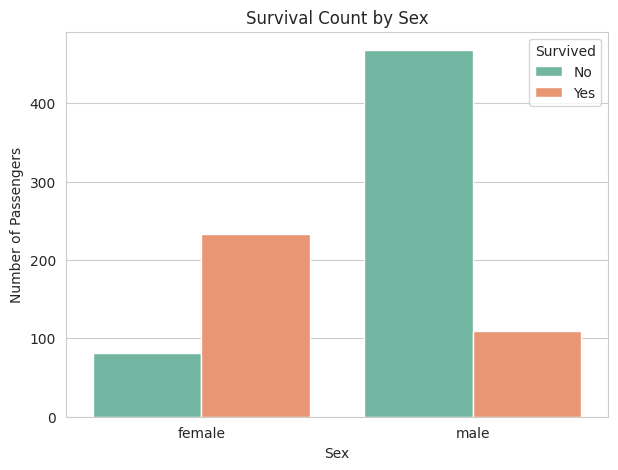

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Sex", hue="Survived", palette="Set2")
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

**Insight:** A much larger share of female passengers survived compared to male passengers.
This lines up with the "women and children first" evacuation policy used on the Titanic.

### Chart 4: Overall Survival Rate (Pie Chart)
Question: What proportion of all passengers survived?

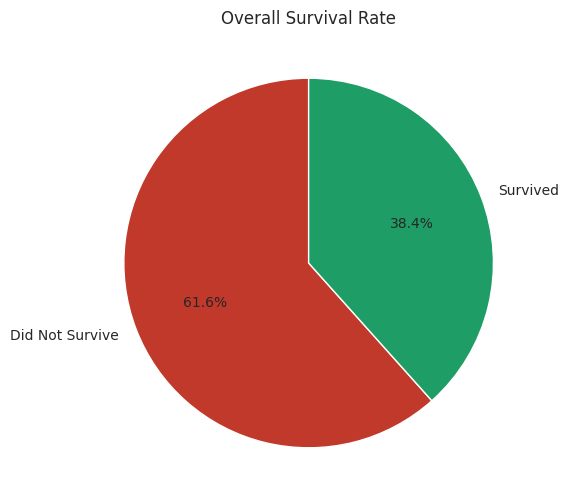

In [20]:
survived_counts = df["Survived"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(survived_counts, labels=["Did Not Survive", "Survived"], autopct="%1.1f%%",
        colors=["#C0392B", "#1F9D66"], startangle=90)
plt.title("Overall Survival Rate")
plt.show()

**Insight:** Only about 38% of passengers survived overall, meaning the majority (around 62%)
did not survive.

### Chart 5: Survival Rate by Age Group (Line Chart)
Question: Did survival rate change across different age groups?

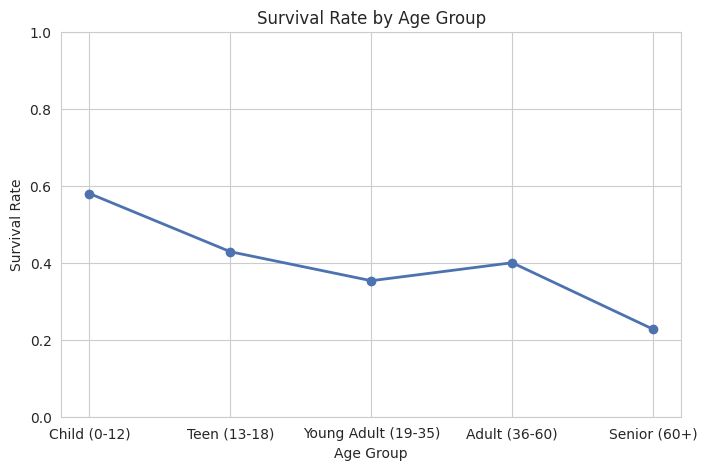

In [21]:
# group ages into bins so we can see a trend
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-35)", "Adult (36-60)", "Senior (60+)"]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

survival_by_age = df.groupby("AgeGroup", observed=True)["Survived"].apply(lambda x: (x == 1).mean())

plt.figure(figsize=(8,5))
plt.plot(survival_by_age.index, survival_by_age.values, marker="o", color="#4C72B0", linewidth=2)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

**Insight:** Children had the highest survival rate, which again matches the "women and
children first" policy. Survival rate drops for teens and adults, though it varies somewhat
across the older age groups too, likely reflecting the smaller number of passengers in those
groups.

## Conclusion

After cleaning the Titanic dataset (handling missing Age/Cabin/Embarked values, removing
duplicates, and fixing data types), the visualizations show some clear patterns: most passengers
travelled in 3rd class, women and children had noticeably higher survival rates than adult men,
and only about 38% of passengers survived overall. These patterns match what's historically known
about the Titanic disaster and the evacuation priorities at the time.